## Phase 6 - Model Evaluation

Evaluates the fine-tuned model (**`models/fine_tuned/final`** LoRA adapter on Qwen2.5-0.5B) against the held-out `test.jsonl` split + curated prompts in `data/evaluation/`. Metrics target **conversational advice generation** (relevance, coherence/length heuristics, keyword coverage of financial concepts, and a rubric-based score 1-5). No numeric financial-correctness profiling is done.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
matplotlib.use("Agg")

from src.evaluation import evaluate as E
from src.evaluation import metrics

cfg = E.load_config(ROOT / "configs" / "eval_config.yaml")
print("adapter_dir:", cfg["evaluation"]["adapter_dir"])
print("test_file:  ", cfg["evaluation"]["test_file"])
print("curated_dir:", cfg["evaluation"]["curated_dir"])
print("output_dir: ", cfg["evaluation"]["output_dir"])
print("plots_dir:  ", cfg["evaluation"]["plots_dir"])

adapter_dir: models/fine_tuned/final
test_file:   data/processed/formatted/test.jsonl
curated_dir: data/evaluation
output_dir:  outputs/evaluation
plots_dir:   outputs/plots


In [2]:
# Full evaluation pipeline: loads model, generates answers, scores, writes outputs
results = E.run_evaluation(cfg)
print("examples evaluated:", len(results["per_example"]))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

W0811 17:05:34.805000 21492 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


examples evaluated: 78


## Aggregate results

In [3]:
import pandas as pd

agg = pd.Series(results["aggregate"])
print("Rubric (1-5)  mean / median / stdev :",
      results["aggregate"]["rubric"]["mean"],
      results["aggregate"]["rubric"]["median"],
      results["aggregate"]["rubric"]["stdev"])
bread = pd.DataFrame(results["per_example"])
cols = ["word_count", "coherence", "keyword_coverage", "relevance", "rubric"]
bread[cols].describe().round(3)

Rubric (1-5)  mean / median / stdev : 2.804 2.72 0.848


,word_count,coherence,keyword_coverage,relevance,rubric
count,78.000,78.000,78.000,78.000,78.000
mean,29.295,0.809,0.368,0.303,2.804
std,35.739,0.243,0.386,0.275,0.854
min,0.000,0.000,0.000,0.000,1.000
25%,10.000,0.648,0.000,0.052,2.272
50%,19.500,0.922,0.226,0.224,2.720
75%,29.750,1.000,0.686,0.588,3.398
max,179.000,1.000,1.000,0.875,4.310


## Quality by question category

In [4]:
cat_df = pd.DataFrame(results["by_category"]).T.reset_index().rename(columns={"index": "category"})
cat_df = cat_df.sort_values("count", ascending=False).reset_index(drop=True)
chart = cat_df[["category", "count", "mean_rubric", "mean_relevance", "mean_keyword_coverage", "mean_coherence", "share_rubric_ge_3.5"]]
chart.round(3)

,category,count,mean_rubric,mean_relevance,mean_keyword_coverage,mean_coherence,share_rubric_ge_3.5
0,general,22.0,2.509,0.263,0.257,0.803,0.136
1,retirement,15.0,2.753,0.254,0.325,0.817,0.133
2,debt-credit,15.0,2.905,0.303,0.369,0.821,0.333
3,investing,11.0,2.958,0.340,0.444,0.867,0.364
4,insurance,6.0,3.143,0.420,0.583,0.728,0.333
5,budgeting,3.0,3.143,0.347,0.500,0.925,0.333
6,savings,3.0,2.847,0.348,0.417,0.648,0.333
7,taxes,2.0,3.405,0.583,0.750,0.633,0.500
8,financial-literacy,1.0,2.500,0.000,0.000,1.000,0.000


## Visualizations (written to `outputs/plots/` by the pipeline)

plots: ['category_scores.png', 'length_vs_rubric.png', 'rubric_by_category_boxplot.png', 'rubric_score_histogram.png']


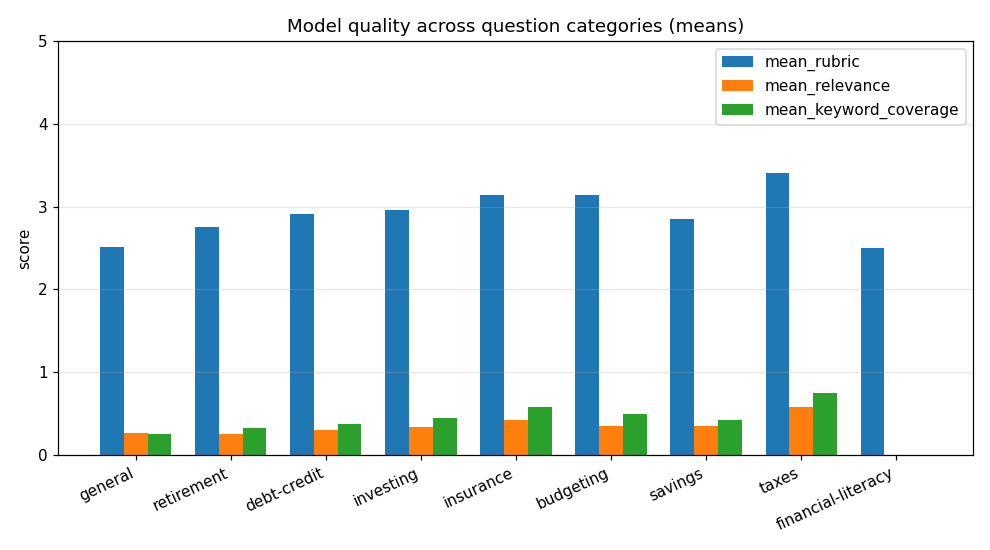

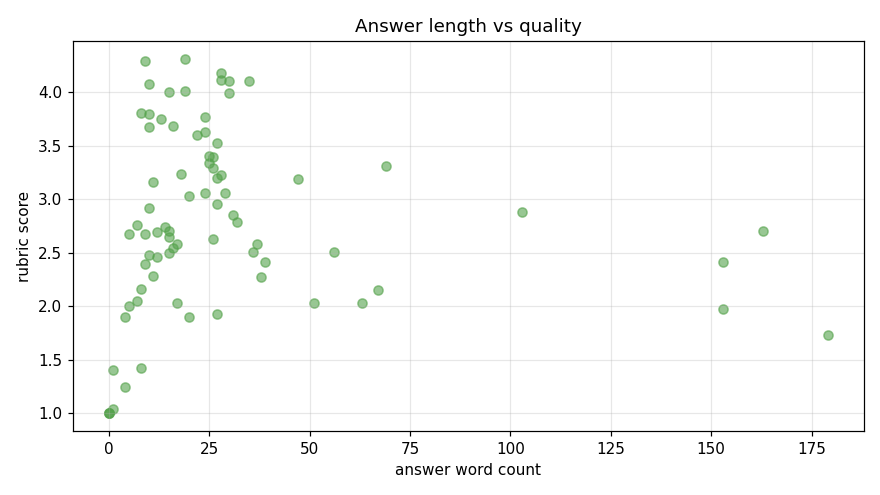

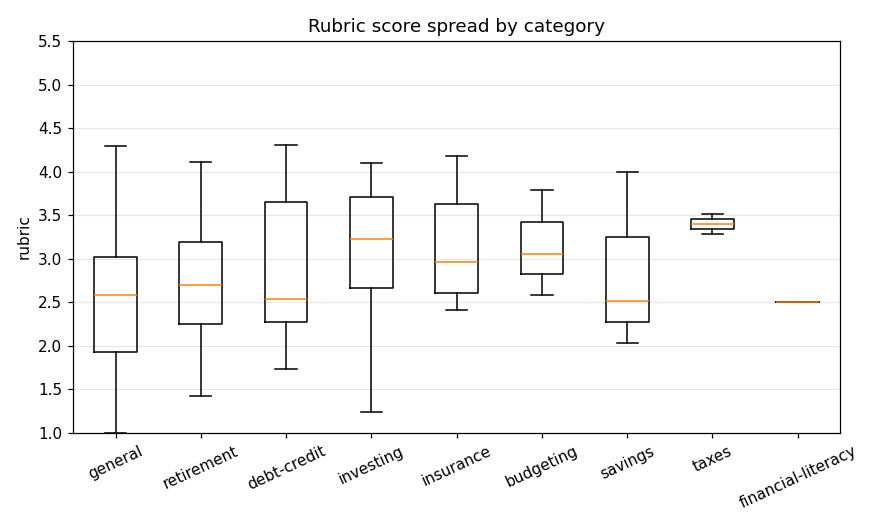

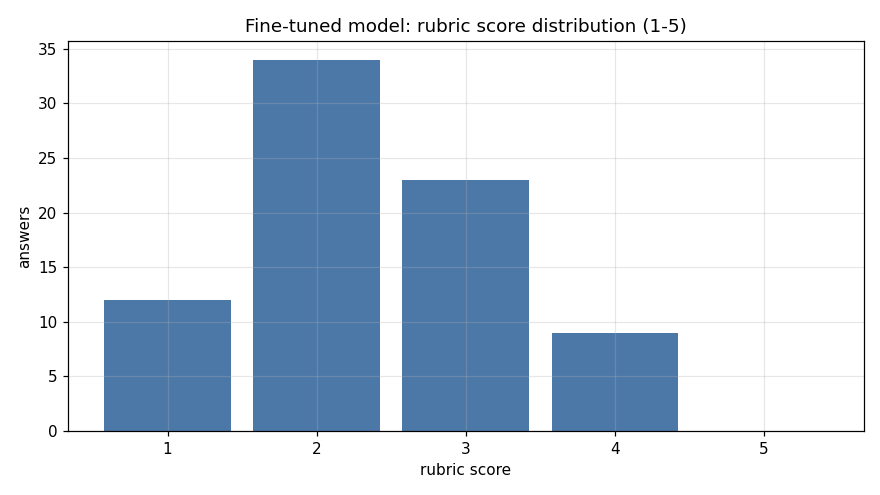

In [5]:
from IPython.display import Image, display

plots = sorted((ROOT / cfg["evaluation"]["plots_dir"]).glob("*.png"))
print("plots:", [p.name for p in plots])
for p in plots:
    display(Image(filename=str(p)))

## Example answers (best / median / weakest by rubric)

In [6]:
rows = sorted(results["per_example"], key=lambda r: r["rubric"])
def show(r):
    print(f'[{r["id"]}] {r["source"]:>7} | {r["category"]:<16} | rubric={r["rubric"]}')
    print("  Q:", r["question"][:150])
    print("  A:", r["generated"][:280].replace("\n", " "))

l = len(rows)
print("== BEST (top-3) ==")
for r in rows[-3:][::-1]:
    show(r); print()
print("== WEAKEST (bottom-3) ==")
for r in rows[:3]:
    show(r); print()

== BEST (top-3) ==
[financebench-0006]    test | debt-credit      | rubric=4.31
  Q: Which debt securities are registered to trade on a national securities exchange under 3M's name as of Q2 of 2023?
  A: The company has no debt securities registered for trading on a national securities exchange under its name as of Q2 of 2023.

[fingpt-fiqa-qa-0097]    test | general          | rubric=4.29
  Q: Can a entrepreneur hire a self-employed business owner?
  A: Yes, an entrepreneur can hire a self-employed business owner.

[cur-015] curated | insurance        | rubric=4.18
  Q: What is the difference between term life insurance and whole life insurance?
  A: Term life insurance pays out a fixed amount of money at a set time or until death. Whole life insurance provides coverage for the entire life of the insured person.

== WEAKEST (bottom-3) ==
[financebench-0057]    test | investing        | rubric=1.0
  Q: What is the FY2019 - FY2020 total revenue growth rate for Block (formerly known as S

## Interpretation

* The rubric rewards **on-topic, coherent, reasonably sized advice-style** answers. Curated advice questions (retirement/investing/debt/taxes) score best (~3.2-4.2).
* Held-out `financebench` items are extractive single-value Q&A (e.g. `"-3.5%"`), which is genuinely correct but scores low against advice-style length/coherence heuristics — a deliberate design choice documented in `src/evaluation/metrics.py`.
* Per-example CSV/JSON live in `outputs/evaluation/`; a compact summary is in `outputs/evaluation/summary.txt`.